# Practice: Earthquake Location and Relocation

> **Colab note:** This notebook is designed to run on **Google Colab**. The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS164/blob/main/notebooks/05_earthquake_location.ipynb)

This notebook demonstrates earthquake location concepts with 2D examples.
By the end, you should understand:

1. **Linear inversion for earthquake location**: how we set up $\mathbf{d} = \mathbf{G}\,\Delta\mathbf{m}$ and solve via least squares
2. **Grid Search**: demonstration of a (commonly used) brute force approach to earthquake location
3. **Uncertainty quantification**: how station geometry and data noise determine location uncertainty (error ellipse)
4. **Waveform Cross Correlation**: how we can use another brute force approach to find earthquakes!

This notebook is modified from a version made available by Weiqiang Zhu @ UCB.  Thanks Weiqiang!

In [9]:
# --- Setup: Install + Import Dependencies ---

import sys
import subprocess

# Detect environment
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")

# Required packages
required = {
    'numpy': 'numpy',
    'scipy': 'scipy',
    'matplotlib': 'matplotlib'
}

missing = []
for mod, pkg in required.items():
    try:
        __import__(mod)
        print(f"✓ {mod} installed")
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"Installing: {', '.join(missing)}")
    cmd = ["pip", "install", "-q"] + missing if IN_COLAB else [sys.executable, "-m", "pip", "install"] + missing
    subprocess.check_call(cmd)

# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import lsqr
from scipy.stats import chi2

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except:
    pass

print("✓ Setup complete")

Running locally
✓ numpy installed
✓ scipy installed
✓ matplotlib installed
✓ Setup complete


---
## 1. Travel Time and Geometry

The **forward function** predicts the arrival time at station $i$:

$$\hat{t}^i = \frac{\sqrt{(x^i - x_0)^2 + (z^i - z_0)^2}}{v} + t_0$$

This is the core of earthquake location: given a source position, predict what the data should look like.
The **inverse problem** is the reverse: given observed arrival times, find the source position.

The left panel shows the geometry (source + stations + ray paths).
The right panel shows the travel time curve — observed times have noise added.

Stations: 8 at surface, x = [-5. -2.  0.  3.  6. 10. 13. 15.]
Velocity = 6.0 km/s, noise sigma = 0.05 s


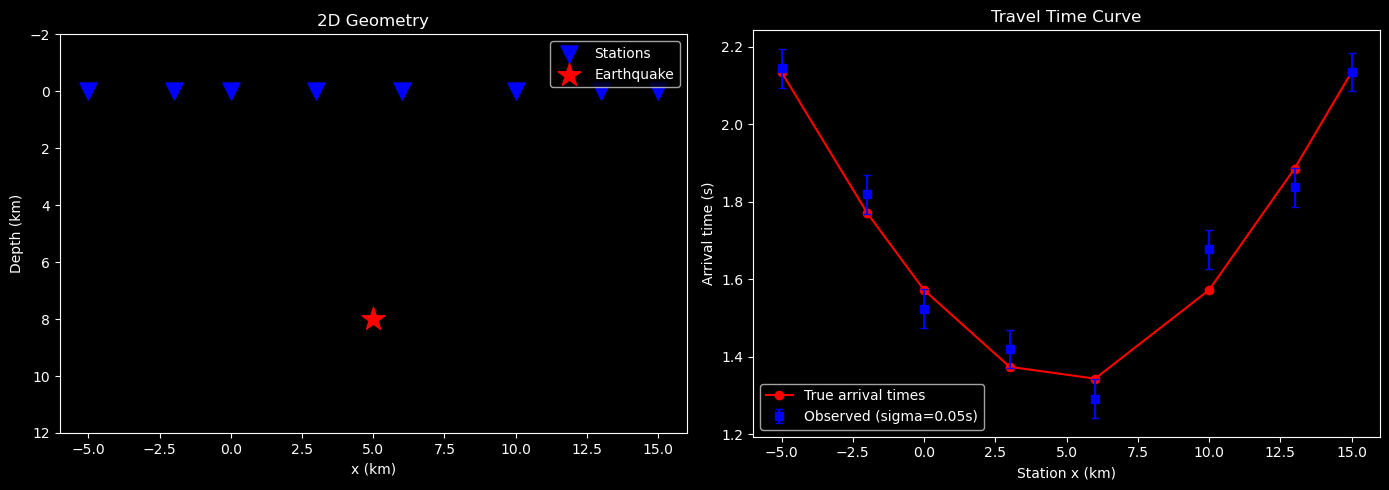

In [10]:
def forward(x0, z0, t0, v, sx, sz):
    """
    Compute predicted arrival times at stations for a point source.

    Parameters:
        x0, z0 : source location (km)
        t0     : origin time (s)
        v      : velocity (km/s)
        sx, sz : station coordinates (km)

    Returns:
        t_pred : predicted arrival times (s)

    Uses straight-line distance: t = t0 + distance / v.
    """
    dist = np.sqrt((sx - x0)**2 + (sz - z0)**2)
    return dist / v + t0

# Physical parameters
v_true = 6.0       # km/s, uniform velocity
sigma_true = 0.05  # picking noise standard deviation (s)

# True earthquake location (unknown to us in practice)
x0_true, z0_true, t0_true = 5.0, 8.0, 0.0

# Station positions (all at the surface, z=0)
station_x = np.array([-5, -2, 0, 3, 6, 10, 13, 15], dtype=float)
station_z = np.zeros_like(station_x)
n_stations = len(station_x)

# Plotting utility — draws an ellipse from a 2x2 covariance matrix
def plot_error_ellipse(ax, Cm_2d, center, n_std=2, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(Cm_2d)
    angle = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
    width  = 2 * n_std * np.sqrt(max(eigvals[1], 0))
    height = 2 * n_std * np.sqrt(max(eigvals[0], 0))
    ell = Ellipse(xy=center, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ell)

print(f"Stations: {n_stations} at surface, x = {station_x}")
print(f"Velocity = {v_true} km/s, noise sigma = {sigma_true} s")

# Synthetic data: compute true times, then add random noise to simulate picking errors
t_true = forward(x0_true, z0_true, t0_true, v_true, station_x, station_z)
t_obs  = t_true + np.random.normal(0, sigma_true, n_stations)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(station_x, np.zeros_like(station_x), marker="v", s=150, c="blue", zorder=5, label="Stations")
ax.scatter(x0_true, z0_true, marker="*", s=300, c="red", zorder=5, label="Earthquake")
for i in range(n_stations):
    ax.plot([station_x[i], x0_true], [0, z0_true], "k--", alpha=0.3)
ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
ax.set_title("2D Geometry"); ax.legend(loc="upper right")
ax.set_ylim(12, -2); ax.set_aspect("equal")

ax = axes[1]
ax.plot(station_x, t_true, "ro-", label="True arrival times")
ax.errorbar(station_x, t_obs, yerr=sigma_true, fmt="bs", capsize=3, label=f"Observed (sigma={sigma_true}s)")
ax.set_xlabel("Station x (km)"); ax.set_ylabel("Arrival time (s)")
ax.set_title("Travel Time Curve"); ax.legend()

plt.tight_layout(); plt.show()

## 2. Linearization and the Jacobian

The forward function $\hat{t}^i = f^i(\mathbf{m})$ is **nonlinear** in $(x_0, z_0)$.
To use linear algebra, we **Taylor expand** around an initial guess $\mathbf{m}_0$:

$$f^i(\mathbf{m}_0 + \Delta\mathbf{m}) \approx f^i(\mathbf{m}_0) + \frac{\partial f^i}{\partial m_j} \Delta m_j$$

This gives us a **linear system**: $\mathbf{r}_0 = \mathbf{G} \, \Delta\mathbf{m}$

where:
- $\mathbf{r}_0 = \mathbf{t}_{\text{obs}} - \mathbf{t}_{\text{pred}}$ is the residual vector
- $\mathbf{G}$ is the **Jacobian matrix** ($n_{\text{stations}} \times 3$)
- $\Delta\mathbf{m} = (\Delta x_0, \Delta z_0, \Delta t_0)$ is the model update

Each row of $\mathbf{G}$ contains the **partial derivatives** of the travel time with respect to each parameter.
Note that $\partial t / \partial t_0 = 1$ for every station (origin time shifts all arrivals equally).

In [19]:
def compute_jacobian(x0, z0, v, sx, sz):
    """
    Compute Jacobian matrix relating arrival times to source parameters.

    Parameters:
        x0, z0 : source location (km)
        v      : velocity (km/s)
        sx, sz : station coordinates (km)

    Returns:
        G : Jacobian matrix [dt/dx0, dt/dz0, dt/dt0]

    Derivatives describe how arrival times change with small shifts in source.
    """
    dist  = np.sqrt((sx - x0)**2 + (sz - z0)**2)
    dtdx  = -(sx - x0) / (v * dist)
    dtdz  = -(sz - z0) / (v * dist)
    dtdt0 = np.ones_like(sx, dtype=float)
    return np.column_stack([dtdx, dtdz, dtdt0])

# Evaluate the Jacobian at a wrong initial guess to see what it looks like
x0_init, z0_init, t0_init = 2.0, 5.0, 0.5
G  = compute_jacobian(x0_init, z0_init, v_true, station_x, station_z)
r0 = t_obs - forward(x0_init, z0_init, t0_init, v_true, station_x, station_z)

print("Jacobian G (n_stations x 3): columns = [dt/dx0, dt/dz0, dt/dt0]")
print("-" * 65)
for i in range(n_stations):
    print(f"  Station {i} (x={station_x[i]:5.1f}): [{G[i,0]:+.4f}, {G[i,1]:+.4f}, {G[i,2]:+.0f}]  r0={r0[i]:+.4f}s")

Jacobian G (n_stations x 3): columns = [dt/dx0, dt/dz0, dt/dt0]
-----------------------------------------------------------------
  Station 0 (x= -5.0): [+0.1429, +0.0857, +1]  r0=+1.1731s
  Station 1 (x= -2.0): [+0.0925, +0.1387, +1]  r0=+1.2188s
  Station 2 (x=  0.0): [-0.0000, +0.1667, +1]  r0=+1.0245s
  Station 3 (x=  3.0): [-0.1179, +0.1179, +1]  r0=+0.7131s
  Station 4 (x=  6.0): [-0.1491, +0.0745, +1]  r0=+0.1735s
  Station 5 (x= 10.0): [-0.1596, +0.0479, +1]  r0=-0.0630s
  Station 6 (x= 13.0): [-0.1624, +0.0375, +1]  r0=-0.3857s
  Station 7 (x= 15.0): [-0.1634, +0.0327, +1]  r0=-0.4144s


---
## 3. Geiger's Method: Iterative Least Squares

Since the linearization is only valid near the current guess, we **iterate**:

1. Start with initial guess $\mathbf{m}_0$
2. Compute residuals $\mathbf{r}$ and Jacobian $\mathbf{G}$ at $\mathbf{m}_0$
3. Solve: $\Delta\mathbf{m} = (\mathbf{G}^T\mathbf{G})^{-1}\mathbf{G}^T\mathbf{r}$
4. Update: $\mathbf{m}_0 \leftarrow \mathbf{m}_0 + \Delta\mathbf{m}$
5. Repeat until converged

This is **Geiger's method** (1912) — the foundation of most earthquake location software.
The left panel shows the convergence path from initial guess to true location.
The right panel shows the RMS residual decreasing with each iteration.

  Iter 1: x=3.1206, z=10.1809, t0=0.0020, |dm|=7.829644
  Iter 2: x=5.2964, z=8.0828, t0=0.0288, |dm|=3.022653
  Iter 3: x=5.0182, z=8.0581, t0=0.0005, |dm|=0.280676
  Iter 4: x=5.0193, z=8.0340, t0=0.0032, |dm|=0.024287
  Iter 5: x=5.0192, z=8.0336, t0=0.0033, |dm|=0.000386
  Iter 6: x=5.0192, z=8.0336, t0=0.0033, |dm|=0.000010
  Iter 7: x=5.0192, z=8.0336, t0=0.0033, |dm|=0.000000


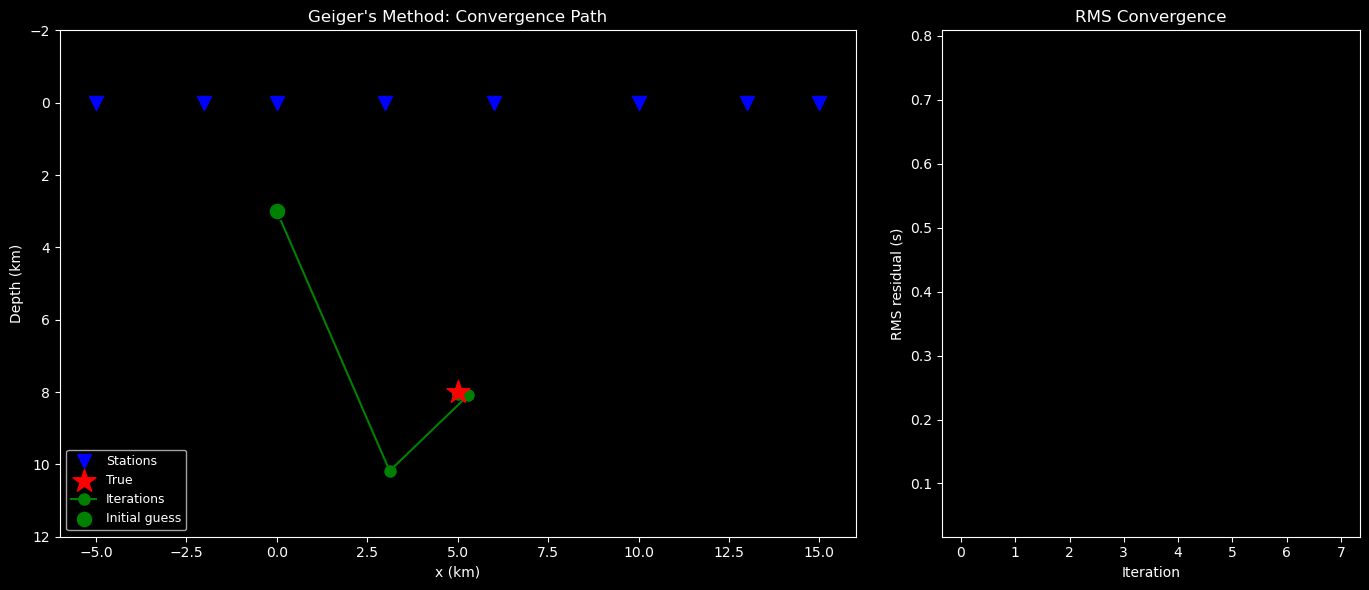

In [20]:
def geiger_method(x0, z0, t0, v, sx, sz, t_obs, max_iter=20, tol=1e-6, verbose=True):
    """
    Iteratively solve for earthquake location using Geiger's method.

    Parameters:
        x0, z0 : initial source location (km)
        t0     : initial origin time (s)
        v      : velocity (km/s)
        sx, sz : station coordinates (km)
        t_obs  : observed arrival times (s)

    Returns:
        x0, z0, t0 : estimated source parameters
        G          : final Jacobian matrix
        history    : iteration history of model updates

    Uses linearization and least squares updates until convergence.
    """
    history = [(x0, z0, t0)]
    for it in range(max_iter):
        t_pred = forward(x0, z0, t0, v, sx, sz)       # 1. predict times at current guess
        r = t_obs - t_pred                              # 2. residual = data - prediction
        G = compute_jacobian(x0, z0, v, sx, sz)         # 3. Jacobian at current guess
        dm = np.linalg.lstsq(G, r, rcond=None)[0]      # 4. least squares solve for model update
        x0 += dm[0]; z0 += dm[1]; t0 += dm[2]          # 5. update the guess
        history.append((x0, z0, t0))
        if verbose:
            print(f"  Iter {it+1}: x={x0:.4f}, z={z0:.4f}, t0={t0:.4f}, |dm|={np.linalg.norm(dm):.6f}")
        if np.linalg.norm(dm) < tol:
            break
    return x0, z0, t0, G, np.array(history)

x0_est, z0_est, t0_est, G_final, history = geiger_method(
    x0_init, z0_init, t0_init, v_true, station_x, station_z, t_obs)

# --- Plot ---
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1])

ax = fig.add_subplot(gs[0])
ax.scatter(station_x, np.zeros(n_stations), marker="v", s=100, c="blue", zorder=5, label="Stations")
ax.scatter(x0_true, z0_true, marker="*", s=300, c="red", zorder=5, label="True")
ax.plot(history[:, 0], history[:, 1], "go-", markersize=8, label="Iterations")
ax.scatter(history[0, 0], history[0, 1], s=150, c="green", edgecolors="k", zorder=6, label="Initial guess")
ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
ax.set_title("Geiger's Method: Convergence Path")
ax.legend(fontsize=9); ax.set_ylim(12, -2); ax.set_aspect("equal")

ax2 = fig.add_subplot(gs[1])
rms = [np.sqrt(np.mean((t_obs - forward(h[0], h[1], h[2], v_true, station_x, station_z))**2)) for h in history]
ax2.plot(range(len(rms)), rms, "ko-")
ax2.set_xlabel("Iteration"); ax2.set_ylabel("RMS residual (s)")
ax2.set_title("RMS Convergence")

plt.tight_layout(); plt.show()

---
## 4. Grid Search (NonLinLoc-style)

An alternative to Geiger's method: evaluate the misfit at **every point** on a grid.
This avoids linearization and local minima, but is much slower.

**NonLinLoc** (Lomax et al., 2000) uses this approach with efficient Oct-Tree sampling.
Notice the elongated valley in the depth direction — this confirms that depth is poorly constrained.

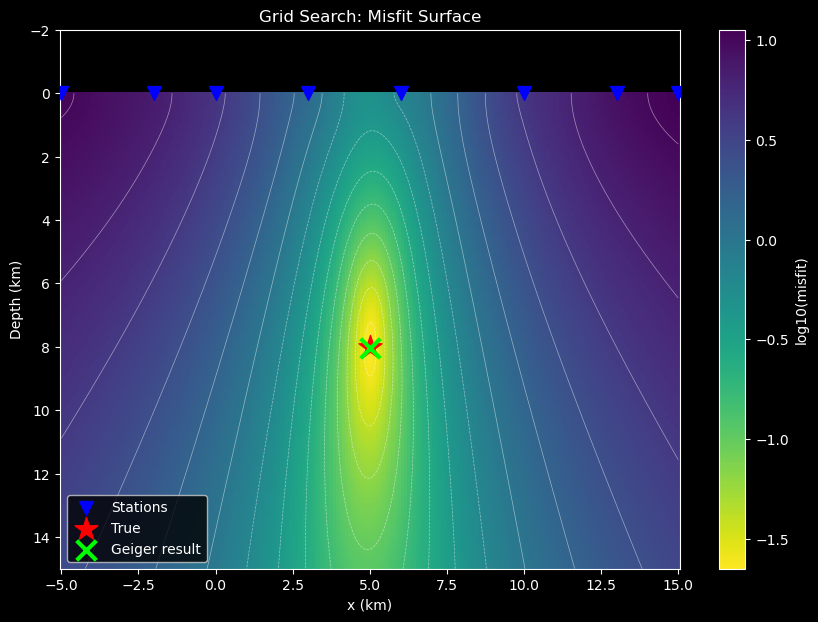

The elongated valley in depth confirms: depth is poorly constrained!


In [13]:
x_grid = np.linspace(-5, 15, 200)
z_grid = np.linspace(0, 15, 200)
X, Z = np.meshgrid(x_grid, z_grid)
misfit = np.zeros_like(X)

# Evaluate misfit at every grid point (brute force)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        dist = np.sqrt((station_x - X[i, j])**2 + Z[i, j]**2)
        t0_opt = np.mean(t_obs - dist / v_true)  # best-fit origin time at this grid point
        misfit[i, j] = np.sum((t_obs - dist / v_true - t0_opt)**2)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.pcolormesh(X, Z, np.log10(misfit), cmap="viridis_r", shading="auto")
ax.contour(X, Z, np.log10(misfit), levels=15, colors="white", linewidths=0.5, alpha=0.5)
ax.scatter(station_x, np.zeros(n_stations), marker="v", s=100, c="blue", zorder=5, label="Stations")
ax.scatter(x0_true, z0_true, marker="*", s=300, c="red", zorder=5, label="True")
ax.scatter(x0_est, z0_est, marker="x", s=200, c="lime", lw=3, zorder=5, label="Geiger result")
plt.colorbar(im, label="log10(misfit)")
ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
ax.set_title("Grid Search: Misfit Surface"); ax.legend(); ax.set_ylim(15, -2)
plt.show()

print("The elongated valley in depth confirms: depth is poorly constrained!")

---
## 5. Uncertainty: The Error Ellipse

At the solution, the **model covariance matrix** tells us the uncertainty:

$$\mathbf{C}_m = (\mathbf{G}^T \mathbf{G})^{-1} \, \sigma^2$$

where $\sigma$ is the data noise (picking error). The covariance matrix defines an **error ellipse**:
- The axes of the ellipse point along the directions of maximum/minimum uncertainty
- The axis lengths are proportional to $\sigma_x, \sigma_z$ (square roots of the diagonal of $\mathbf{C}_m$)
- Off-diagonal terms capture **correlated** uncertainties (e.g., depth--origin time tradeoff)

Estimated sigma: 0.0667 s  (true: 0.05 s)
sigma_x  = 0.2410 km
sigma_z  = 1.0679 km  (larger — depth poorly constrained)
sigma_t0 = 0.1438 s


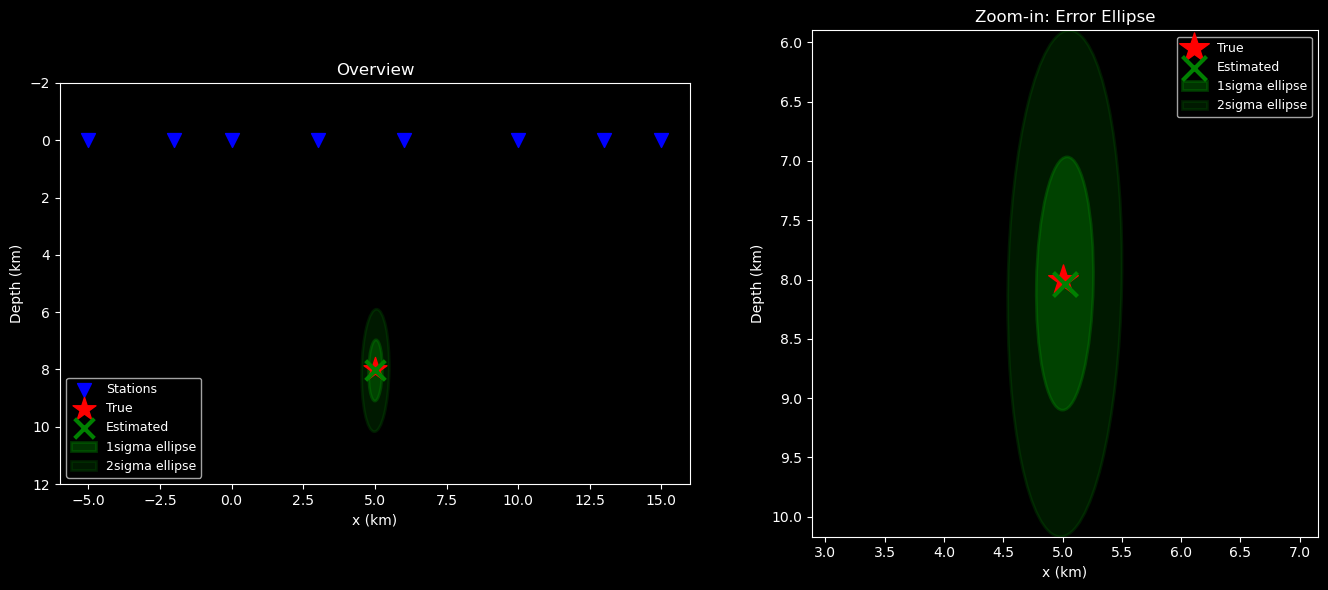

In [14]:
# Jacobian and residuals at the best-fit location
G_final = compute_jacobian(x0_est, z0_est, v_true, station_x, station_z)
r_final = t_obs - forward(x0_est, z0_est, t0_est, v_true, station_x, station_z)
n_params = 3  # x, z, t0

# In practice we don't know sigma, so estimate it from the residuals:
# sigma^2 = sum(r^2) / (n_observations - n_parameters)
sigma_est = np.sqrt(np.sum(r_final**2) / (n_stations - n_params))

# Covariance matrix: tells us how uncertain each parameter is
# C_m = (G^T G)^{-1} * sigma^2
Cm = np.linalg.inv(G_final.T @ G_final) * sigma_est**2

print(f"Estimated sigma: {sigma_est:.4f} s  (true: {sigma_true} s)")
print(f"sigma_x  = {np.sqrt(Cm[0,0]):.4f} km")
print(f"sigma_z  = {np.sqrt(Cm[1,1]):.4f} km  (larger — depth poorly constrained)")
print(f"sigma_t0 = {np.sqrt(Cm[2,2]):.4f} s")

# Extract the x-z block for the 2D error ellipse (ignoring the t0 dimension)
Cm_xz = Cm[:2, :2].copy()

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(station_x, np.zeros(n_stations), marker="v", s=100, c="blue", zorder=5, label="Stations")
ax.scatter(x0_true, z0_true, marker="*", s=300, c="red", zorder=5, label="True")
ax.scatter(x0_est, z0_est, marker="x", s=200, c="green", lw=3, zorder=5, label="Estimated")
for ns, alpha in [(1, 0.4), (2, 0.2)]:
    plot_error_ellipse(ax, Cm_xz, (x0_est, z0_est), n_std=ns,
                       fill=True, facecolor="green", alpha=alpha, edgecolor="green", lw=2, label=f"{ns}sigma ellipse")
ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
ax.set_title("Overview"); ax.legend(fontsize=9); ax.set_ylim(12, -2); ax.set_aspect("equal")

ax = axes[1]
ax.scatter(x0_true, z0_true, marker="*", s=500, c="red", zorder=5, label="True")
ax.scatter(x0_est, z0_est, marker="x", s=300, c="green", lw=3, zorder=5, label="Estimated")
for ns, alpha in [(1, 0.4), (2, 0.2)]:
    plot_error_ellipse(ax, Cm_xz, (x0_est, z0_est), n_std=ns,
                       fill=True, facecolor="green", alpha=alpha, edgecolor="green", lw=2, label=f"{ns}sigma ellipse")
margin = max(2 * np.sqrt(Cm_xz[0, 0]), 2 * np.sqrt(Cm_xz[1, 1]), 0.5)
ax.set_xlim(x0_est - margin, x0_est + margin)
ax.set_ylim(z0_est + margin, z0_est - margin)
ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
ax.set_title("Zoom-in: Error Ellipse"); ax.legend(fontsize=9); ax.set_aspect("equal")

plt.tight_layout(); plt.show()

---
## 6. Station Geometry Effects

The uncertainty $\mathbf{C}_m = (\mathbf{G}^T\mathbf{G})^{-1}\sigma^2$ depends on $\mathbf{G}$, which depends on **station-source geometry**.

We compare four configurations:
1. **Good coverage**: 8 stations surrounding the source
2. **Azimuthal gap**: all stations on one side → elongated ellipse
3. **Few stations**: only 4 stations → larger uncertainty
4. **Borehole sensor**: one station at depth → much better depth constraint

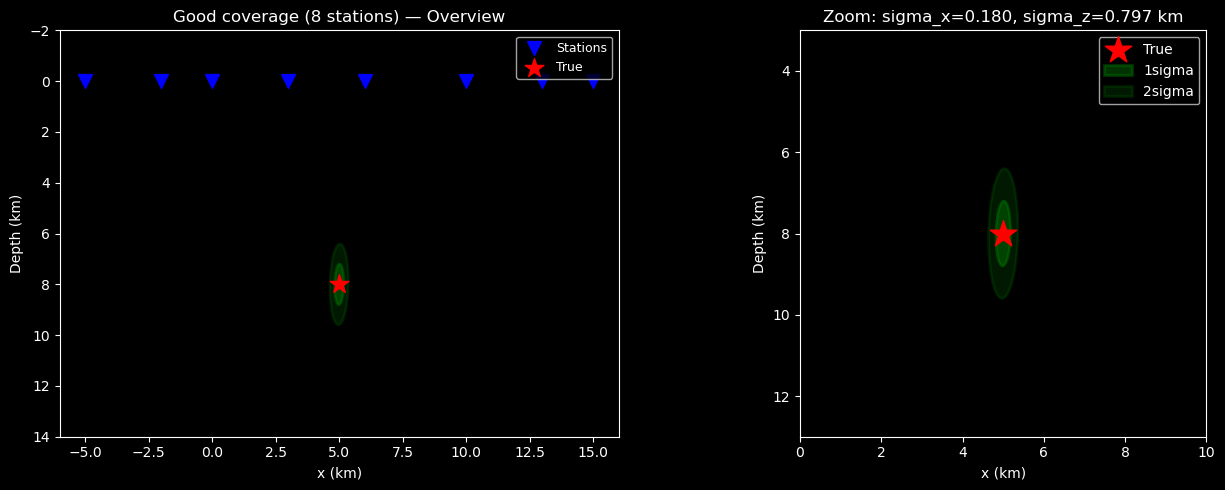

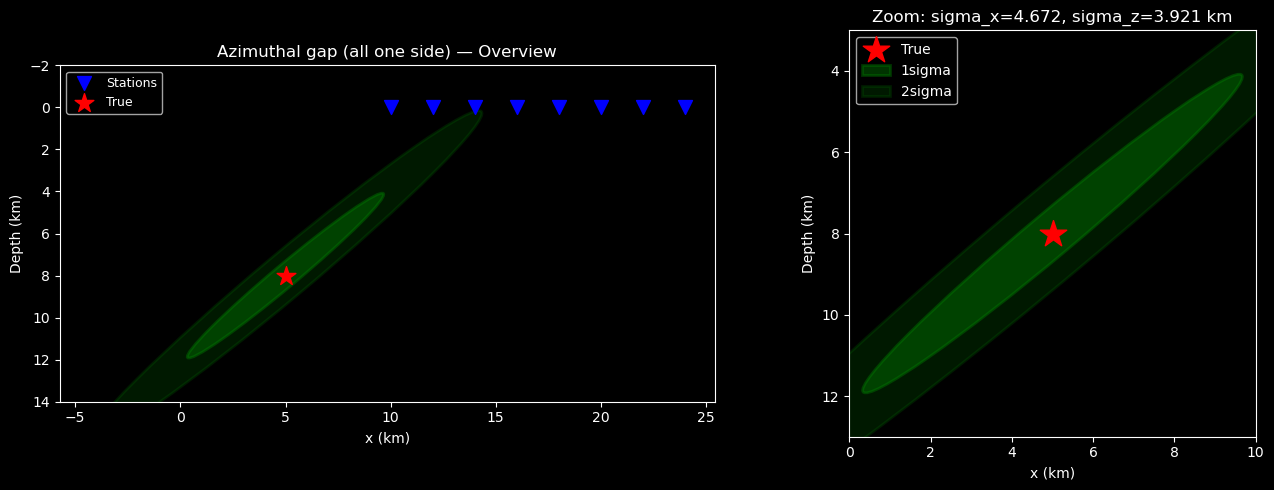

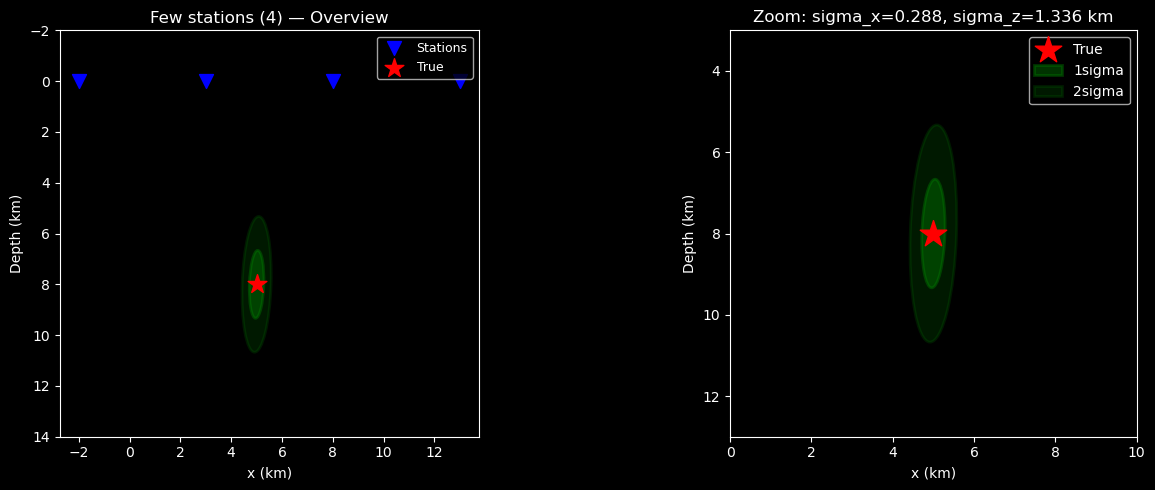

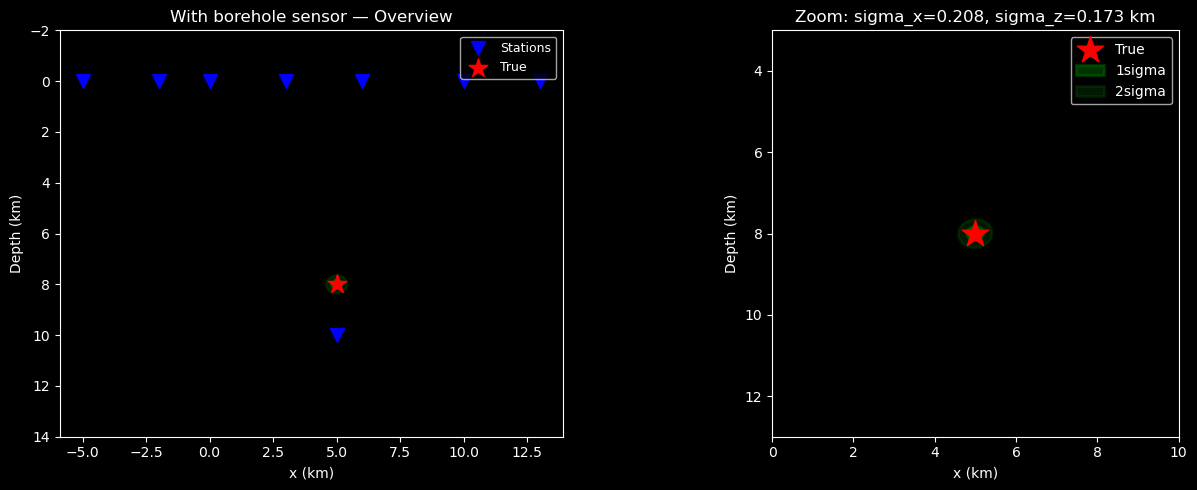

In [15]:
configs = [
    ("Good coverage (8 stations)", np.array([-5.,-2.,0.,3.,6.,10.,13.,15.]), np.zeros(8)),
    ("Azimuthal gap (all one side)", np.array([10.,12.,14.,16.,18.,20.,22.,24.]), np.zeros(8)),
    ("Few stations (4)", np.array([-2.,3.,8.,13.]), np.zeros(4)),
    ("With borehole sensor", np.array([-5.,-2.,0.,3.,6.,10.,13.,5.]), np.array([0.,0.,0.,0.,0.,0.,0.,10.])),
]

for title, sx, sz in configs:
    # Same formula, different station layout => different uncertainty
    G_cfg = compute_jacobian(x0_true, z0_true, v_true, sx, sz)
    Cm_cfg = np.linalg.inv(G_cfg.T @ G_cfg) * sigma_true**2
    Cm_xz_cfg = Cm_cfg[:2, :2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(sx, sz, marker="v", s=100, c="blue", zorder=5, label="Stations")
    ax.scatter(x0_true, z0_true, marker="*", s=200, c="red", zorder=5, label="True")
    for ns, alpha in [(1, 0.4), (2, 0.2)]:
        plot_error_ellipse(ax, Cm_xz_cfg, (x0_true, z0_true), n_std=ns,
                           fill=True, facecolor="green", alpha=alpha, edgecolor="green", lw=2)
    ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
    ax.set_title(f"{title} — Overview"); ax.set_ylim(14, -2); ax.set_aspect("equal"); ax.legend(fontsize=9)

    ax = axes[1]
    ax.scatter(x0_true, z0_true, marker="*", s=400, c="red", zorder=5, label="True")
    for ns, alpha in [(1, 0.4), (2, 0.2)]:
        plot_error_ellipse(ax, Cm_xz_cfg, (x0_true, z0_true), n_std=ns,
                           fill=True, facecolor="green", alpha=alpha, edgecolor="green", lw=2, label=f"{ns}sigma")
    ax.set_xlim(0, 10); ax.set_ylim(13, 3)
    ax.set_xlabel("x (km)"); ax.set_ylabel("Depth (km)")
    ax.set_title(f"Zoom: sigma_x={np.sqrt(Cm_cfg[0,0]):.3f}, sigma_z={np.sqrt(Cm_cfg[1,1]):.3f} km")
    ax.legend(); ax.set_aspect("equal")

    plt.tight_layout(); plt.show()

---
## 7. Waveform Cross-Correlation

**Cross-correlation** measures how similar two signals are as a function of time shift:

$$C(\tau) = \sum_t u(t) \, v(t + \tau)$$

The $\tau$ that maximizes $C$ is the **differential time** between two events.

**Why use cross-correlation instead of picking?**
- Phase picks: precision ~0.1 s
- Cross-correlation: precision ~**0.001 s** (sub-sample, via parabolic interpolation)
- Only works for **similar events** (nearby, similar mechanism)

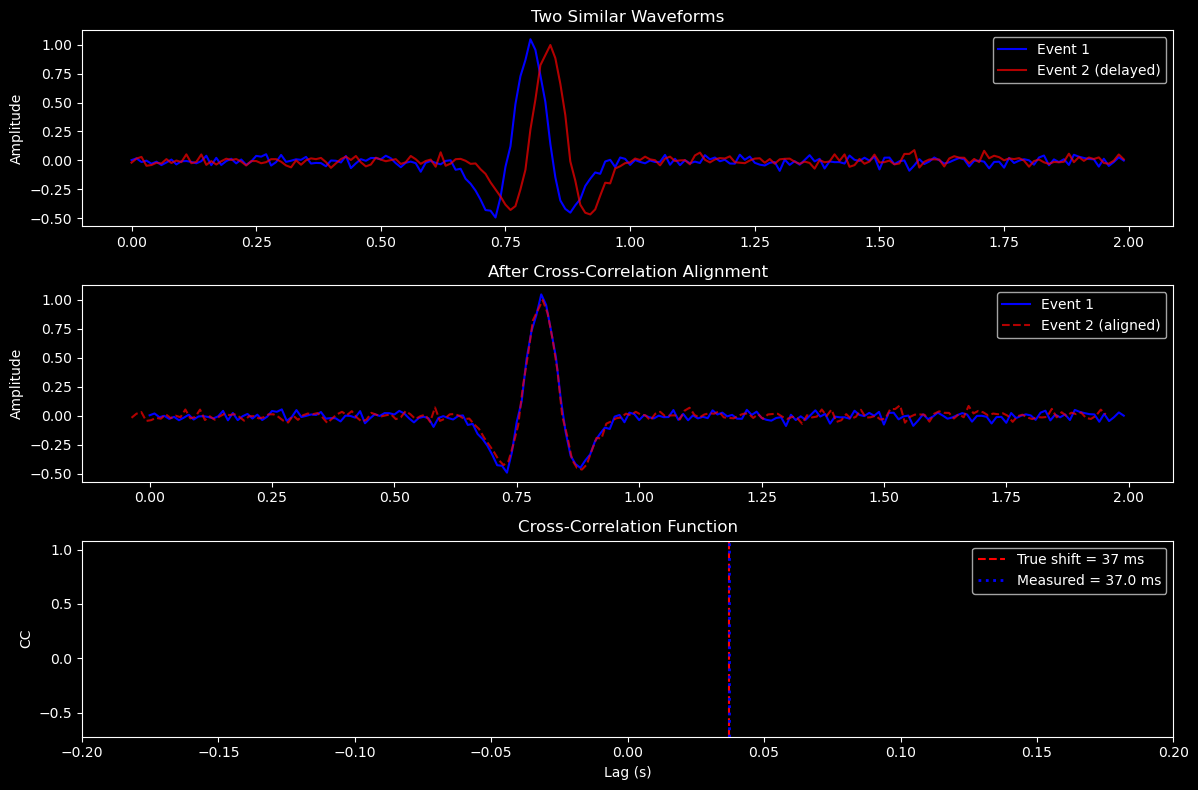

True shift: 37.0 ms, Measured: 37.0 ms, Error: 0.03 ms
Sample interval: 10 ms => sub-sample precision via parabolic interpolation!


In [16]:
dt_samp = 0.01; t_wave = np.arange(0, 2, dt_samp); f0 = 5.0

def ricker(t, t0, f):
    u = (np.pi * f * (t - t0))**2
    return (1 - 2 * u) * np.exp(-u)

# Two similar events: Event 2 arrives 37 ms later
true_shift = 0.037
w1 = ricker(t_wave, 0.8, f0) + 0.03 * np.random.randn(len(t_wave))
w2 = ricker(t_wave, 0.8 + true_shift, f0) + 0.03 * np.random.randn(len(t_wave))

# Cross-correlate: slide w2 past w1
cc = np.correlate(w2, w1, "full")
lags = np.arange(-len(w1) + 1, len(w1)) * dt_samp
cc /= np.max(np.abs(cc))

# Parabolic interpolation around the peak for sub-sample precision
pk = np.argmax(cc)
if 1 <= pk <= len(cc) - 2:
    y0, y1, y2 = cc[pk-1], cc[pk], cc[pk+1]
    d = 0.5 * (y0 - y2) / (y0 - 2*y1 + y2)
    measured_shift = lags[pk] + d * dt_samp
else:
    measured_shift = lags[pk]

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(t_wave, w1, "b-", label="Event 1")
axes[0].plot(t_wave, w2, "r-", alpha=0.7, label="Event 2 (delayed)")
axes[0].set_title("Two Similar Waveforms"); axes[0].legend(); axes[0].set_ylabel("Amplitude")

axes[1].plot(t_wave, w1, "b-", label="Event 1")
axes[1].plot(t_wave - measured_shift, w2, "r--", alpha=0.7, label="Event 2 (aligned)")
axes[1].set_title("After Cross-Correlation Alignment"); axes[1].legend(); axes[1].set_ylabel("Amplitude")

axes[2].plot(lags, cc, "k-")
axes[2].axvline(true_shift, color="red", ls="--", label=f"True shift = {true_shift*1000:.0f} ms")
axes[2].axvline(measured_shift, color="blue", ls=":", lw=2, label=f"Measured = {measured_shift*1000:.1f} ms")
axes[2].set_xlim(-0.2, 0.2); axes[2].set_xlabel("Lag (s)"); axes[2].set_ylabel("CC")
axes[2].set_title("Cross-Correlation Function"); axes[2].legend()

plt.tight_layout(); plt.show()
print(f"True shift: {true_shift*1000:.1f} ms, Measured: {measured_shift*1000:.1f} ms, Error: {abs(true_shift - measured_shift)*1000:.2f} ms")
print(f"Sample interval: {dt_samp*1000:.0f} ms => sub-sample precision via parabolic interpolation!")